Loading CSV Data...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Processing r/technology...
   - Encoding 748 posts (using GPU)...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

   - Reducing to 2D...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


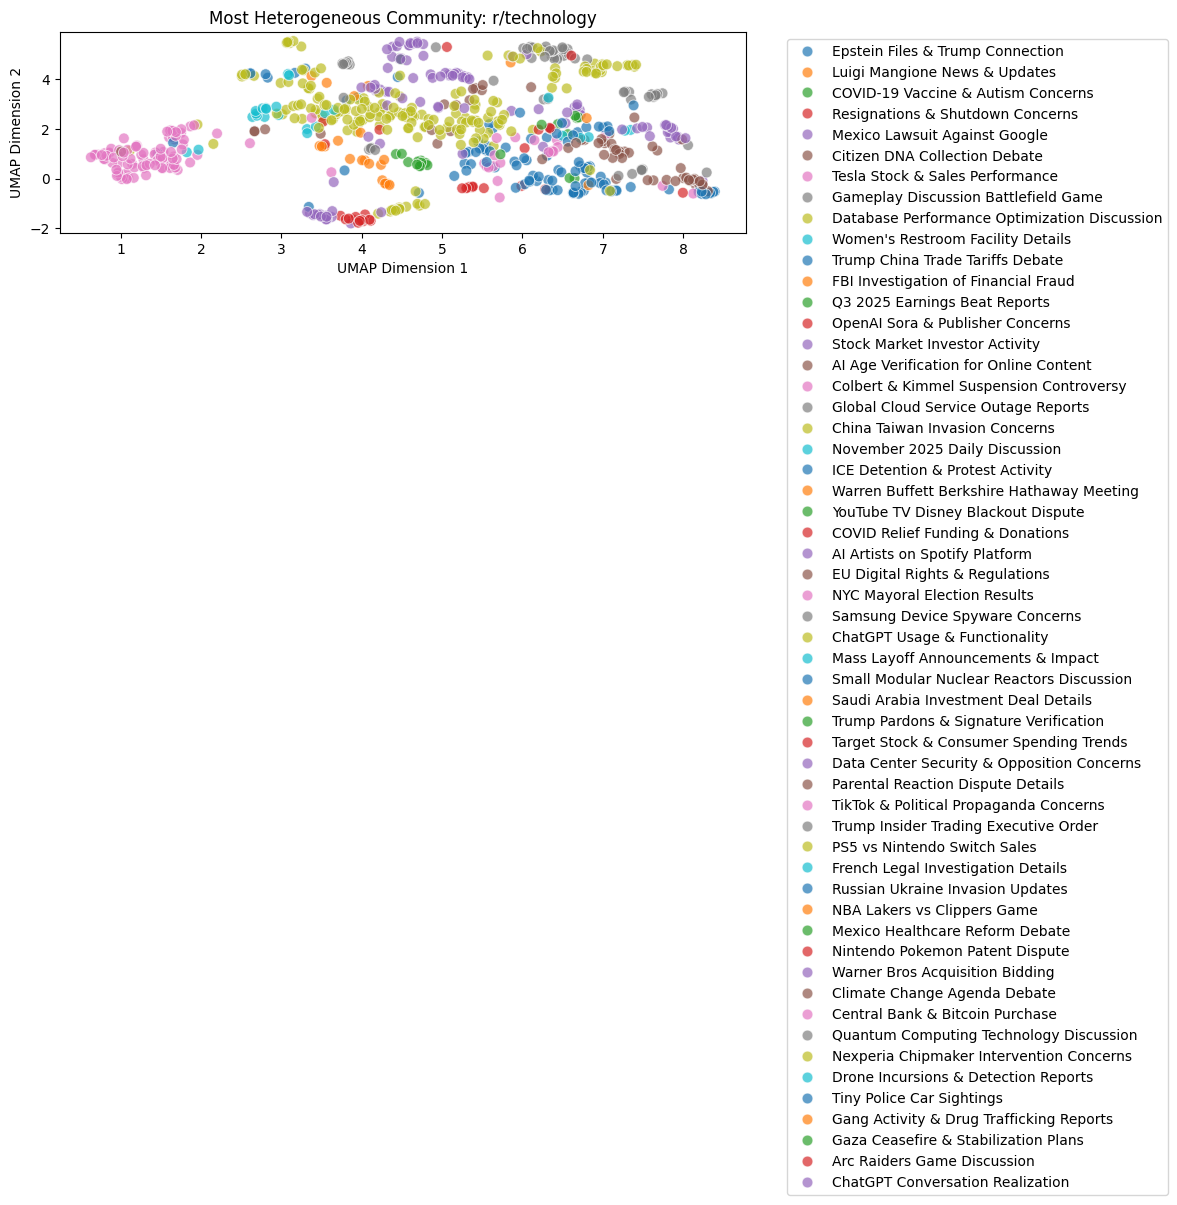

Saved plot_heterogeneous.png
Processing r/nba...
   - Encoding 1017 posts (using GPU)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

   - Reducing to 2D...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


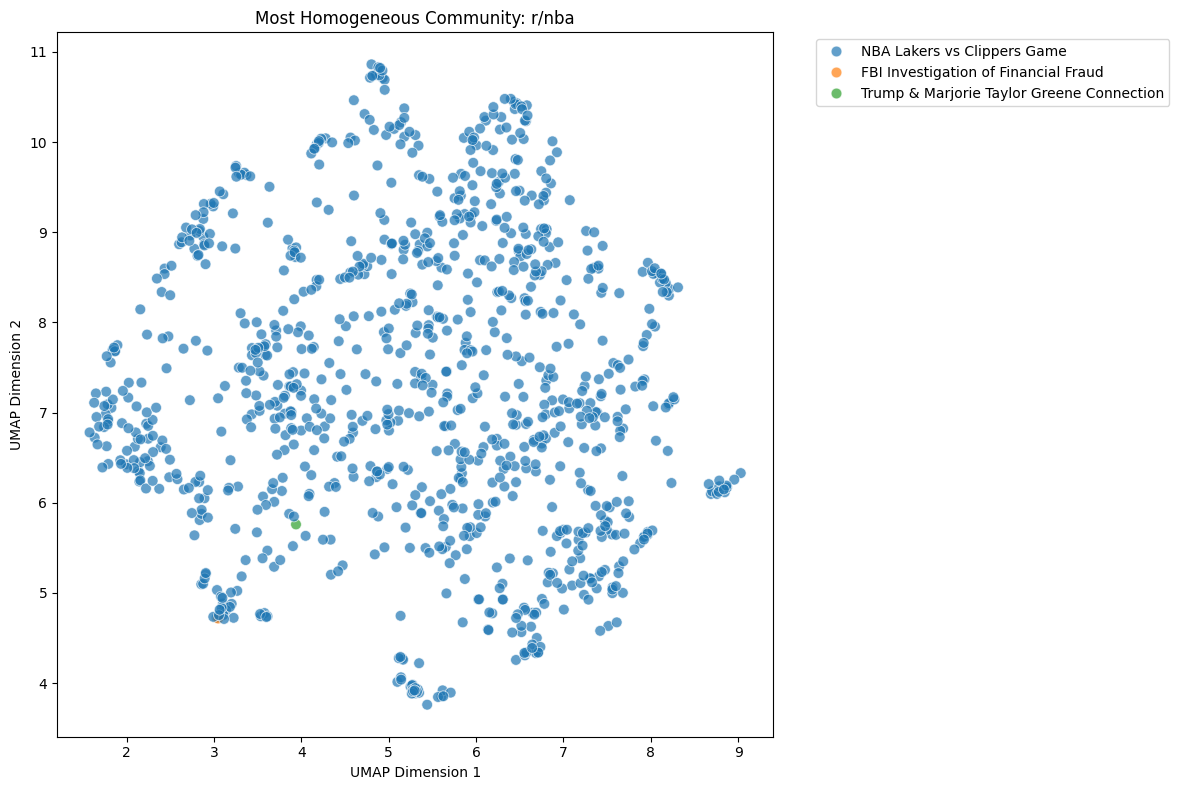

Saved plot_homogeneous.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
import umap
import numpy as np

# 1. Load Data
print("Loading CSV Data...")
df = pd.read_csv("reddit_data_with_topics_analyzed_clean_labels.csv")

# Identify communities again 
community_stats = df.groupby('subreddit')['Topic'].nunique()
hetero_name = community_stats.idxmax() # Most topics
homo_name = community_stats.idxmin()   # Fewest topics

# 2. Load a standard embedding model 
print("Downloading embedding model (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def visualize_community_fresh(community_name, plot_title, filename):
    print(f"Processing r/{community_name}...")

    # Filter data for this community
    subset = df[df['subreddit'] == community_name].copy()
    docs = subset['combined_text'].tolist()

    # A. Generate Embeddings (Text -> Numbers)
    print(f"   - Encoding {len(docs)} posts (using GPU)...")
    embeddings = embedder.encode(docs, show_progress_bar=True, device='cuda')

    # B. Reduce to 2D using UMAP
    print("   - Reducing to 2D...")
    reducer = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.1, random_state=42)
    reduced_embeddings = reducer.fit_transform(embeddings)

    # C. Add coordinates to dataframe
    subset['x'] = reduced_embeddings[:, 0]
    subset['y'] = reduced_embeddings[:, 1]

    # D. Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=subset,
        x='x',
        y='y',
        hue='Label',
        palette='tab10',
        legend='full',
        s=60,
        alpha=0.7
    )

    plt.title(f"{plot_title}: r/{community_name}")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")

    # Adjust legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f"Saved {filename}")

# 3. Run the visualization
visualize_community_fresh(hetero_name, "Most Heterogeneous Community", "plot_heterogeneous.png")
visualize_community_fresh(homo_name, "Most Homogeneous Community", "plot_homogeneous.png")